In [21]:
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255
X_train = X_train.reshape(len(X_train), np.prod(X_train.shape[1:]))
X_test = X_test.reshape(len(X_test), np.prod(X_test.shape[1:]))
print(X_train.shape)
print(X_test.shape)


(60000, 784)
(10000, 784)


In [23]:
# Vectoriser l'image d'entrée
input_img= Input(shape=(784,))

In [24]:
# Faire un encodage de l'image d'entrée en une représentation plus petite
encoded = Dense(units=128, activation='relu')(input_img) 
encoded = Dense(units=64, activation='relu')(encoded) 
encoded = Dense(units=32, activation='relu')(encoded) 
decoded = Dense(units=64, activation='relu')(encoded) 
decoded = Dense(units=128, activation='relu')(decoded) 
decoded = Dense(units=784, activation='sigmoid')(decoded)

In [25]:
# Faire un modèle d'autoencodeur qui prend l'image d'entrée et la reconstruit
autoencoder=Model(input_img, decoded) 
encoder = Model(input_img, encoded) 
autoencoder.summary() 
encoder.summary()
# Compiler le modèle d'autoencodeur et l'entraîner sur les données d'entraînement
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy']) 
# Entraîner le modèle d'autoencodeur sur les données d'entraînement
autoencoder.fit(X_train, X_train, epochs=50, batch_size=256,shuffle=True, validation_data=(X_test, X_test))

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - binary_accuracy: 0.7837 - loss: 0.2464 - val_binary_accuracy: 0.8026 - val_loss: 0.1659
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - binary_accuracy: 0.8052 - loss: 0.1482 - val_binary_accuracy: 0.8067 - val_loss: 0.1347
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - binary_accuracy: 0.8088 - loss: 0.1297 - val_binary_accuracy: 0.8087 - val_loss: 0.1230
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - binary_accuracy: 0.8103 - loss: 0.1208 - val_binary_accuracy: 0.8103 - val_loss: 0.1163
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - binary_accuracy: 0.8111 - loss: 0.1152 - val_binary_accuracy: 0.8110 - val_loss: 0.1117
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - binary_accuracy: 0.8118 - loss: 0.1103 - val_binary_accuracy: 0.8112 - val_loss: 0.1072
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - binary_accuracy: 0.8124 - loss: 0.1064 - val_binary_accuracy: 0.8119 - val_loss: 0.1

In [ ]:
# Afficher les courbes d'erreur
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbe d\'erreur de l\'autoencodeur')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
encoded_imgs = encoder.predict(X_test) 
predicted = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


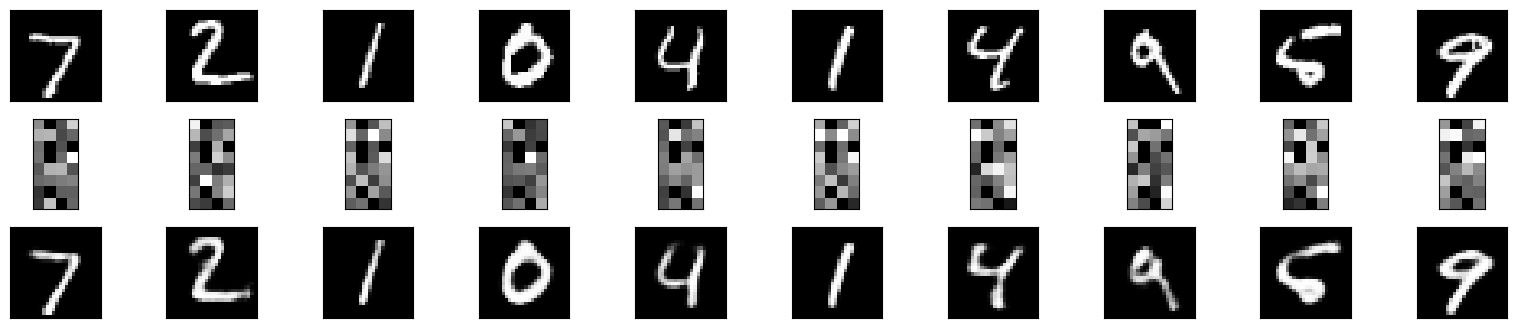

In [29]:
plt.figure(figsize=(40, 4))
for i in range(10):
    # display original images
    ax = plt.subplot(3, 20, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # display encoded images
    ax = plt.subplot(3, 20, i + 1 + 20)
    plt.imshow(encoded_imgs[i].reshape(8,4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # display reconstructed images
    ax = plt.subplot(3, 20, 2*20 +i+ 1)
    plt.imshow(predicted[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()